In [1]:
import sys
sys.path.append('..')

import os
os.environ["KERAS_BACKEND"] = "torch"

import tensorflow as tf
import numpy as np
from keras.models import load_model
from evaluation.metrics import evaluate_model
from evaluation.visualization import plot_history, plot_calibration_curve
from utils.vector_keras import l2_normalize, manhattan_similarity, cosine_similarity
from config.settings import Settings
from datasets.dataset import create_dataset
from datasets.loader import load_splits, save_metrics
from models.calibration import fit_isotonic_regression
from features.vectorizer import TextVectorizerModel
from models.siamese_lstm import SiameseLSTM
from datasets.paths import ProjectPaths


c:\Users\malos\Documents\GitHub\JustShare\server\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
settings = Settings()
print(settings)


batch_size=64 mlp_dropout=0.4 lstm_dropout=0.3 pooling='mean' similarity='cosine' hidden_dim=64 bidirectional=False mlp_layers=[32] concat_features=['diff'] epochs=20 augmented_data=True siamese_name='lstm_mean_cosine' max_len=26 augmented_max_len=26 case=False strip_punctuation=True


In [3]:
paths = ProjectPaths(siamese_name=settings.siamese_name)
print(paths.siamese_dir)


../models\lstm_mean_cosine


In [4]:
splits = {
    "test": paths.processed_dir,
	"dev": paths.processed_dir,
}

datasets = load_splits(splits)

test_df = datasets["test"]
dev_df = datasets["dev"]


In [5]:
settings = Settings()

print(settings)


batch_size=64 mlp_dropout=0.4 lstm_dropout=0.3 pooling='mean' similarity='cosine' hidden_dim=64 bidirectional=False mlp_layers=[32] concat_features=['diff'] epochs=20 augmented_data=True siamese_name='lstm_mean_cosine' max_len=26 augmented_max_len=26 case=False strip_punctuation=True


In [6]:
embedding_matrix = np.load(paths.embedding_path)

vectorizer = TextVectorizerModel.load(paths.vectorizer_dir)

custom_objects={
	"SiameseLSTM": SiameseLSTM,
	"l2_normalize": l2_normalize,
	"manhattan_similarity": manhattan_similarity,
	"cosine_similarity": cosine_similarity,
}

model = load_model(
	paths.siamese_path,
	custom_objects=custom_objects,
	compile=False
)

model.embedding.set_weights([embedding_matrix])


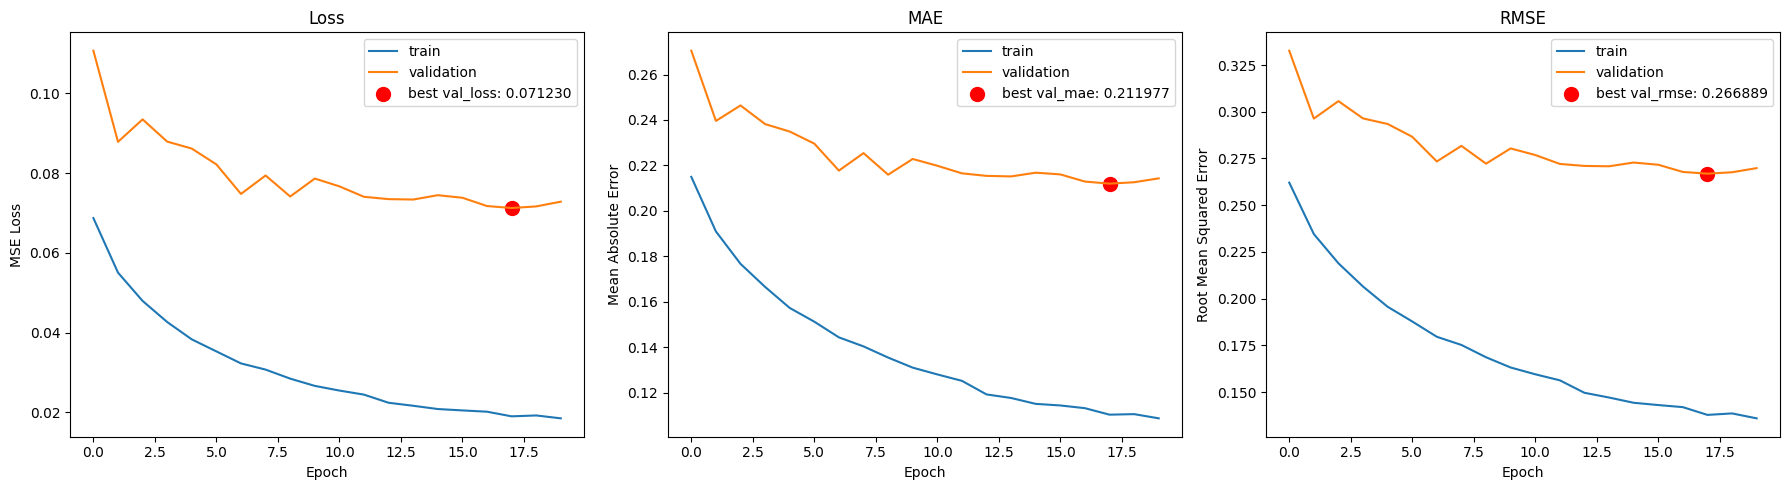

In [7]:
history_dict = np.load(paths.history_path, allow_pickle=True).item()

history_metrics = plot_history(history_dict, paths.siamese_dir)


In [8]:
def get_predictions_and_labels(model: SiameseLSTM, dataset: tf.data.Dataset):
    y_true = np.concatenate([y for _, y in dataset], axis=0)
    y_pred = model.predict(dataset).ravel()
    return y_true, y_pred

test_dataset = create_dataset(test_df, vectorizer, settings.batch_size)
dev_dataset = create_dataset(dev_df, vectorizer, settings.batch_size)

y_true_test, y_pred_test = get_predictions_and_labels(model, test_dataset)
y_true_dev, y_pred_dev = get_predictions_and_labels(model, dev_dataset)


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step


Pearson: 0.6524 | Spearman: 0.6460 | MSE: 0.0710 | MAE: 0.2081 | RMSE: 0.2665 | Bias: -0.1264 | R²: 0.2358


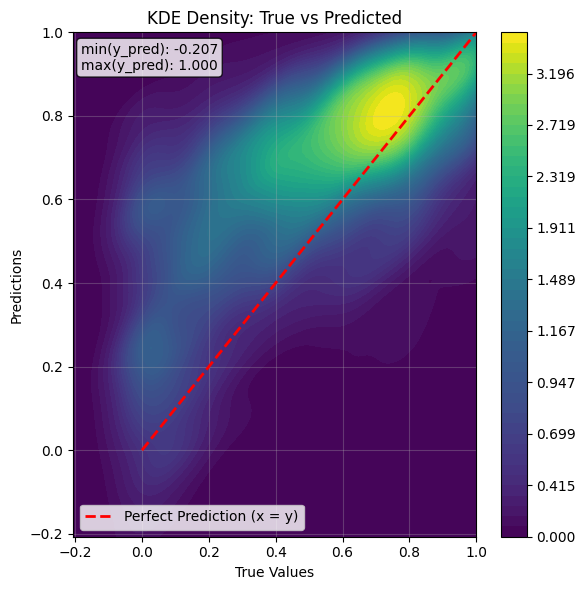

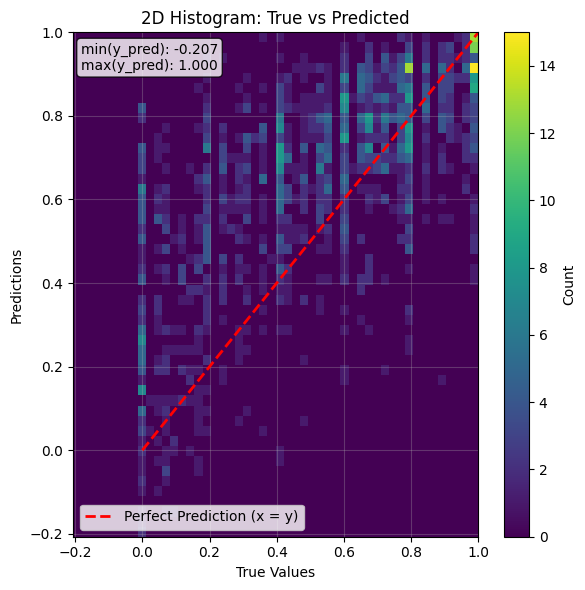

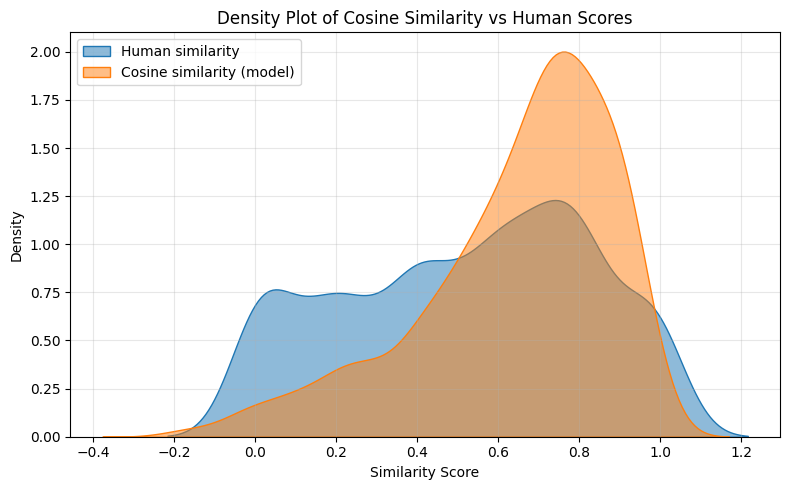

In [9]:
test_metrics = evaluate_model(y_true_test, y_pred_test, paths.test_dir)


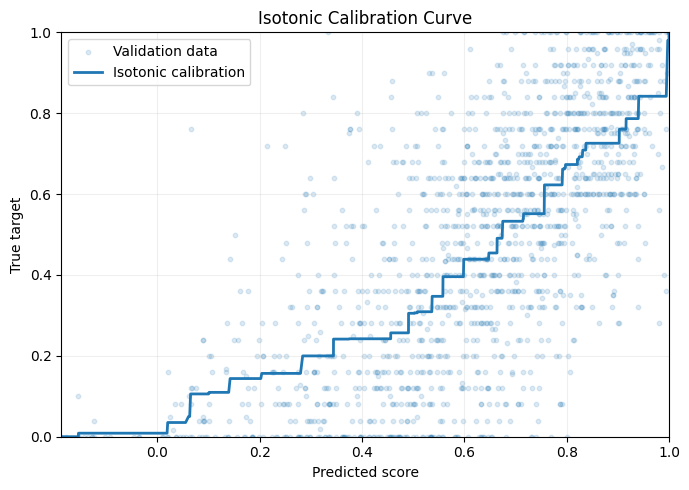

In [10]:
iso = fit_isotonic_regression(y_pred_dev, y_true_dev, paths.iso_path)

plot_calibration_curve(y_pred_dev, y_true_dev, iso, paths.calibration_dir)


Pearson: 0.6596 | Spearman: 0.6466 | MSE: 0.0534 | MAE: 0.1801 | RMSE: 0.2311 | Bias: 0.0215 | R²: 0.4256


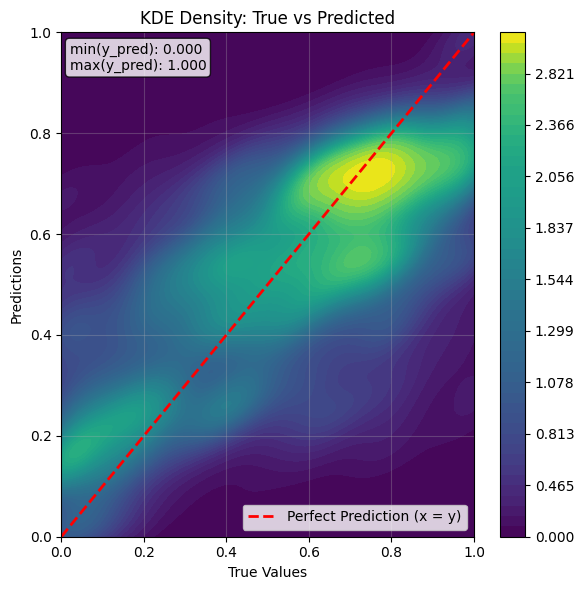

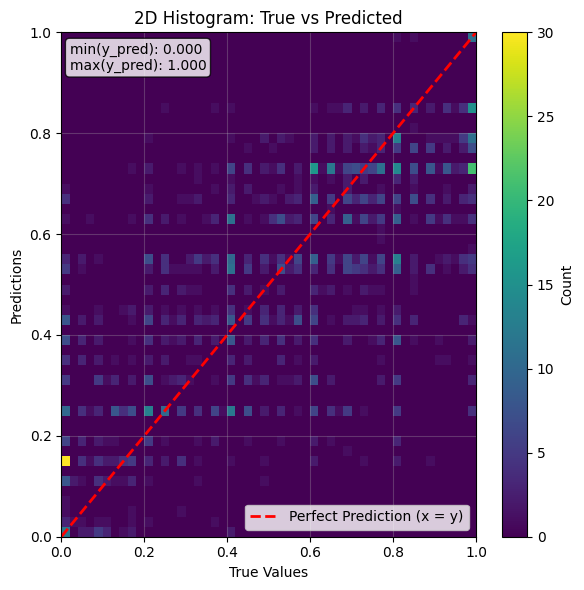

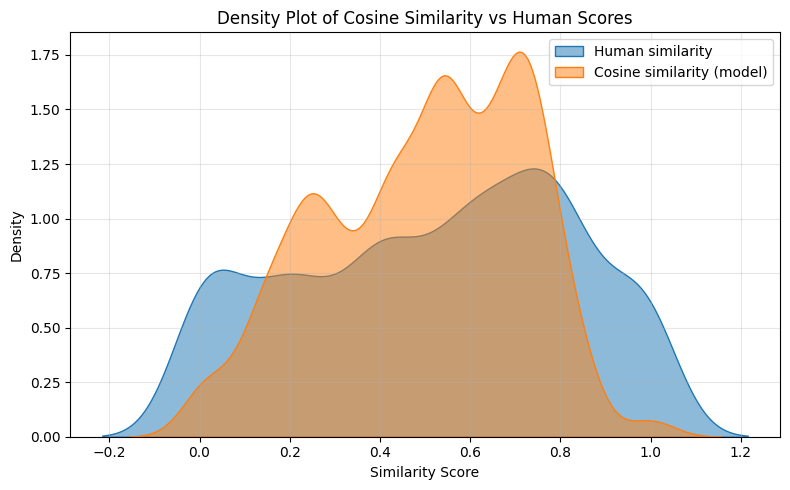

In [11]:
y_calibrated = iso.predict(y_pred_test)

calibration_metrics = evaluate_model(y_true_test, y_calibrated, paths.calibration_dir)


In [12]:
save_metrics(
    model,
    config_path=paths.config_path,
    metrics_path=paths.metrics_path,
    history_metrics=history_metrics,
    test_metrics=test_metrics,
    calibration_metrics=calibration_metrics
)
